# LogSense — Model Training
This notebook trains a machine learning classifier on the 
preprocessed cybersecurity dataset to detect network intrusions.

In [24]:
import numpy as np
import joblib

# Load the preprocessed data we saved in Phase 2
X_train = np.load('../model/X_train_scaled.npy')
X_test = np.load('../model/X_test_scaled.npy')
y_train = np.load('../model/y_train.npy')
y_test = np.load('../model/y_test.npy')

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print("Data loaded successfully!")

Training set: (7629, 17)
Test set: (1908, 17)
Data loaded successfully!


## Step 1 — Train the Classifier
We use a Random Forest classifier — an ensemble of decision trees
that votes on the final prediction. Great for tabular data like ours.

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## Step 2 — Evaluate the Model
We test the model on data it has never seen before (the test set)
and measure how accurately it detects attacks.

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Detailed report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))

# Confusion matrix
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 89.20%

=== Classification Report ===
              precision    recall  f1-score   support

      Benign       0.84      0.99      0.91      1042
      Attack       0.99      0.77      0.87       866

    accuracy                           0.89      1908
   macro avg       0.91      0.88      0.89      1908
weighted avg       0.91      0.89      0.89      1908

=== Confusion Matrix ===
[[1035    7]
 [ 199  667]]


In [27]:
# Save the trained model
joblib.dump(model, '../model/model.pkl')
print("Model saved to model/model.pkl!")

Model saved to model/model.pkl!


## Step 3 — Visualise Results
A visual confusion matrix makes it easy to see model performance at a glance.

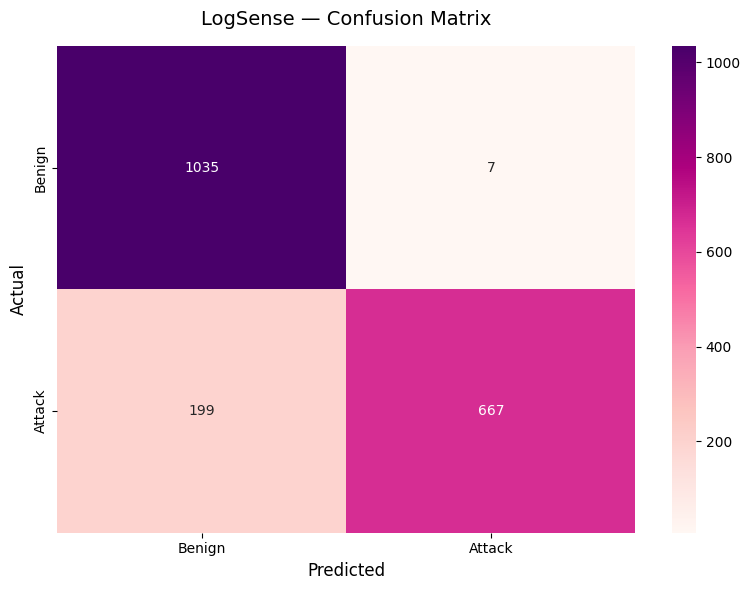

Confusion matrix saved!


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='RdPu',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])

plt.title('LogSense — Confusion Matrix', fontsize=14, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('../model/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

## Results Summary

| Metric | Score |
|---|---|
| Overall Accuracy | 89.20% |
| Attack Precision | 99% |
| Attack Recall | 77% |
| Benign Recall | 99% |
| F1 Score (weighted) | 89% |

**Key takeaways:**
- The model almost never raises a false alarm (99% attack precision)
- It correctly identifies 99% of all benign sessions
- It catches 77% of real attacks — strong for a baseline model with no tuning
- 199 missed attacks is the main area for future improvement

## 📊 Results

| Metric | Score |
|---|---|
| Overall Accuracy | 89.20% |
| Attack Precision | 99% |
| Attack Recall | 77% |
| F1 Score (weighted) | 89% |

![Confusion Matrix](model/confusion_matrix.png)